# Tilt census

A tilt-distance-specific census for anticyclonic (AE) and cyclonic (CE) eddies. The notebook retains the original mirrored-histogram idea but uses compact publication dashboards, smooth shading and embedded weighted box summaries.

Daily distributions give every eddy equal total weight, preventing long tracks from dominating. Per-eddy metrics contain one observation per eddy.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
import sys
HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next(p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists())
sys.path.insert(0, str(ANALYSIS_ROOT))
import seacofs_tilt_tools as tilt

AE_COLOUR = '#C44E52'
CE_COLOUR = '#2878A5'
TYPE_COLOURS = {'AE': AE_COLOUR, 'CE': CE_COLOUR}
PAGE_SIZE = (10, 7)
SAVE_FIGURES = False
FIGURE_DIR = Path('tilt_census_figures')
SMOOTH_SIGMA_BINS = 1.15
UPSTREAM_REGIONS = ['S1', 'U1', 'U2']
DOWNSTREAM_REGIONS = ['S2', 'D1', 'D2']
SUBREGION_ORDER = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

mpl.rcParams.update({'figure.dpi':120,'savefig.dpi':600,'font.size':9.5,
 'axes.titlesize':10.5,'axes.labelsize':9.5,'legend.fontsize':8.5,
 'axes.spines.top':False,'axes.spines.right':False,'axes.linewidth':.8,
 'xtick.direction':'out','ytick.direction':'out','pdf.fonttype':42,'ps.fonttype':42})

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
df_eddies = df_eddies.sort_values(['Cyc','Eddy','Day']).copy()
region_group_map = {'S1':'Shelf','S2':'Shelf','U1':'Upstream','U2':'Upstream','D1':'Downstream','D2':'Downstream'}
sector_map = {**{r:'Upstream + S1' for r in UPSTREAM_REGIONS}, **{r:'Downstream + S2' for r in DOWNSTREAM_REGIONS}}
df_eddies['RegionGroup'] = df_eddies.Region.map(region_group_map)
df_eddies['Sector'] = df_eddies.Region.map(sector_map)
KEYS = ['Cyc','Eddy']
df_eddies['day_index'] = df_eddies.groupby(KEYS).cumcount()
last_index = df_eddies.groupby(KEYS).day_index.transform('max')
df_eddies['norm_time'] = np.where(last_index>0,df_eddies.day_index/last_index,np.nan)
df_eddies['lifetime_days'] = df_eddies.groupby(KEYS).Day.transform(lambda x:x.max()-x.min()+1)
tilt_data = df_eddies.dropna(subset=['TiltDis']).query("Cyc in ['AE','CE']").copy()
# Tilt distance and Rc are both in km, so this ratio is dimensionless.
valid_rc = np.isfinite(tilt_data['Rc']) & (tilt_data['Rc'] > 0)
tilt_data['tilt_over_Rc'] = np.where(valid_rc, tilt_data['TiltDis'] / tilt_data['Rc'], np.nan)
GLOBAL_TILT_LIMIT = float(tilt_data.TiltDis.quantile(.995))
GLOBAL_TILT_BINS = np.linspace(0,GLOBAL_TILT_LIMIT,43)
GLOBAL_TILT_RC_BINS = np.linspace(0,tilt_data.tilt_over_Rc.quantile(.995),43)
df_eddies.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Date,fname,TiltDis,TiltDir,Region,RegionGroup,Sector,day_index,norm_time,lifetime_days
26,2,1462,AE,151.793573,-37.940740,140,40,367.413413,196.922965,0.000038,...,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1,Downstream,Downstream + S2,0,0.000000,32
27,2,1463,AE,151.615529,-38.053390,136,36,356.354073,179.836500,0.000042,...,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1,Downstream,Downstream + S2,1,0.032258,32
28,2,1464,AE,151.505429,-38.086839,133,35,348.312905,173.055772,0.000041,...,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,14.598309,243.722363,D1,Downstream,Downstream + S2,2,0.064516,32
29,2,1465,AE,151.720810,-38.058377,139,37,365.294728,182.464807,0.000036,...,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,16.442587,231.047484,D1,Downstream,Downstream + S2,3,0.096774,32
30,2,1466,AE,151.590538,-38.149537,136,34,357.511090,169.056926,0.000035,...,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,15.693618,216.985055,D1,Downstream,Downstream + S2,4,0.129032,32


## Census summary
Counts remain available for documentation, while the figures below focus on tilt-distance results.

In [2]:
census = (df_eddies.groupby(['Cyc','Sector'],dropna=False)
          .agg(eddy_days=('Eddy','size'),unique_eddies=('Eddy','nunique'),
               tilt_days=('TiltDis','count'),median_tilt=('TiltDis','median')).reset_index())
display(census.round(2))
for cyc in ['AE','CE']:
    g=df_eddies[df_eddies.Cyc==cyc]; eligible=len(g)-6*g.Eddy.nunique()
    print(f'{cyc}: {g.Eddy.nunique():,} eddies; {g.TiltDis.notna().sum():,} tilt estimates; '
          f'{100*g.TiltDis.notna().sum()/eligible:.1f}% eligible-day success')

,Cyc,Sector,eddy_days,unique_eddies,tilt_days,median_tilt
0,AE,Downstream + S2,42584,960,33940,15.03
1,AE,Upstream + S1,22366,622,17227,25.98
2,AE,NaN,2,2,0,NaN
3,CE,Downstream + S2,35347,938,28176,11.71
4,CE,Upstream + S1,27127,729,22313,20.89


AE: 1,446 eddies; 51,167 tilt estimates; 90.9% eligible-day success
CE: 1,536 eddies; 50,489 tilt estimates; 94.8% eligible-day success


## Plotting and per-eddy summaries

In [3]:
def equal_eddy_weights(data):
    return 1.0/data.groupby(KEYS).Eddy.transform('size').astype(float)

def weighted_quantile(values,quantiles,weights=None):
    values=np.asarray(values,float); weights=np.ones(values.size) if weights is None else np.asarray(weights,float)
    ok=np.isfinite(values)&np.isfinite(weights)&(weights>0); values,weights=values[ok],weights[ok]
    if not values.size: return np.full(np.atleast_1d(quantiles).shape,np.nan)
    order=np.argsort(values); values,weights=values[order],weights[order]
    cdf=(np.cumsum(weights)-.5*weights)/weights.sum()
    return np.interp(np.atleast_1d(quantiles),cdf,values)

def gaussian_smooth(y,sigma=SMOOTH_SIGMA_BINS):
    radius=max(1,int(np.ceil(4*sigma))); x=np.arange(-radius,radius+1)
    kernel=np.exp(-.5*(x/sigma)**2); kernel/=kernel.sum()
    return np.convolve(y,kernel,mode='same')

def make_eddy_summary(data):
    rows=[]
    for (cyc,eddy),g in data.groupby(KEYS):
        x=g.TiltDis.dropna().to_numpy()
        if not len(x): continue
        ratio=g.tilt_over_Rc.dropna().to_numpy()
        rows.append({'Cyc':cyc,'Eddy':eddy,'mean_tilt':x.mean(),
          'mean_tilt_over_Rc':ratio.mean() if len(ratio) else np.nan,
          'min_tilt':x.min(),'max_tilt':x.max(),'tilt_range':np.ptp(x),
          'tilt_sd':np.std(x,ddof=1) if len(x)>1 else np.nan,'p90_tilt':np.quantile(x,.9),
          'n_tilt':len(x),'lifetime_days':g.lifetime_days.max()})
    return pd.DataFrame(rows)

def draw_weighted_box(ax,values,weights,y,colour,box_height):
    q05,q25,q50,q75,q95=weighted_quantile(values,[.05,.25,.5,.75,.95],weights)
    half_height=box_height/2
    ax.plot([q05,q95],[y,y],color=colour,lw=1.3,solid_capstyle='round',zorder=5)
    ax.plot([q05,q05],[y-.55*half_height,y+.55*half_height],color=colour,lw=1.1,zorder=5)
    ax.plot([q95,q95],[y-.55*half_height,y+.55*half_height],color=colour,lw=1.1,zorder=5)
    ax.add_patch(Rectangle((q25,y-half_height),q75-q25,box_height,facecolor='white',edgecolor=colour,alpha=.88,lw=1.3,zorder=6))
    ax.plot([q50,q50],[y-half_height,y+half_height],color=colour,lw=2.2,zorder=7)

def mirrored_density_box(ax,data,column,title,xlabel,*,daily=False,bins=None,xlim=None,show_legend=False):
    clean=data.dropna(subset=[column]).copy()
    if bins is None:
        values=clean[column].to_numpy(); hi=np.nanquantile(values,.995)
        bins=np.linspace(max(0,np.nanmin(values)),hi,38)
    centres=.5*(bins[:-1]+bins[1:]); stored={}; peak=0.0
    for cyc,sign in [('AE',1),('CE',-1)]:
        g=clean[clean.Cyc==cyc]; values=g[column].to_numpy()
        weights=equal_eddy_weights(g).to_numpy() if daily else np.ones(len(g))
        hist,_=np.histogram(values,bins=bins,weights=weights); hist=hist/hist.sum()*100 if hist.sum() else hist.astype(float)
        smooth=gaussian_smooth(hist); peak=max(peak,float(np.nanmax(smooth))); colour=TYPE_COLOURS[cyc]
        ax.fill_between(centres,0,sign*smooth,color=colour,alpha=.30,lw=0)
        ax.plot(centres,sign*smooth,color=colour,lw=1.8,label=cyc); stored[cyc]=(values,weights)
    ax.axhline(0,color='.25',lw=.7); ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_:f'{abs(y):g}'))
    ax.set(title=title,xlabel=xlabel,ylabel='Probability (%)'); ax.grid(axis='x',alpha=.14,lw=.6)
    if xlim is not None: ax.set_xlim(xlim)
    box_offset=.30*peak; box_height=.12*peak
    draw_weighted_box(ax,*stored['AE'],box_offset,AE_COLOUR,box_height)
    draw_weighted_box(ax,*stored['CE'],-box_offset,CE_COLOUR,box_height)
    if show_legend: ax.legend(frameon=False,ncol=2,loc='lower right')

def draw_vertical_weighted_box(ax,values,weights,x,colour,box_width):
    q05,q25,q50,q75,q95=weighted_quantile(values,[.05,.25,.5,.75,.95],weights)
    half_width=box_width/2
    ax.plot([x,x],[q05,q95],color=colour,lw=1.3,solid_capstyle='round',zorder=5)
    ax.plot([x-.55*half_width,x+.55*half_width],[q05,q05],color=colour,lw=1.1,zorder=5)
    ax.plot([x-.55*half_width,x+.55*half_width],[q95,q95],color=colour,lw=1.1,zorder=5)
    ax.add_patch(Rectangle((x-half_width,q25),box_width,q75-q25,facecolor='white',edgecolor=colour,alpha=.88,lw=1.3,zorder=6))
    ax.plot([x-half_width,x+half_width],[q50,q50],color=colour,lw=2.2,zorder=7)

def vertical_split_violin_box(ax,groups,column,title,ylabel,*,daily=False,bins=None,show_legend=False):
    if bins is None:
        all_values=np.concatenate([g[column].dropna().to_numpy() for _,g in groups])
        bins=np.linspace(max(0,np.nanmin(all_values)),np.nanquantile(all_values,.995),38)
    centres=.5*(bins[:-1]+bins[1:]); curves={}; peak=0.0
    for group_index,(group_label,data) in enumerate(groups):
        for cyc in ['AE','CE']:
            g=data[data.Cyc==cyc].dropna(subset=[column]); values=g[column].to_numpy()
            weights=equal_eddy_weights(g).to_numpy() if daily else np.ones(len(g))
            hist,_=np.histogram(values,bins=bins,weights=weights)
            hist=hist/hist.sum()*100 if hist.sum() else hist.astype(float)
            smooth=gaussian_smooth(hist); peak=max(peak,float(np.nanmax(smooth)))
            curves[(group_index,cyc)]=(smooth,values,weights)
    half_violin_width=.55
    for group_index,(group_label,data) in enumerate(groups):
        for cyc,sign in [('AE',-1),('CE',1)]:
            smooth,values,weights=curves[(group_index,cyc)]
            width=half_violin_width*smooth/peak if peak>0 else smooth
            edge=group_index+sign*width; colour=TYPE_COLOURS[cyc]
            ax.fill_betweenx(centres,group_index,edge,color=colour,alpha=.30,lw=0)
            ax.plot(edge,centres,color=colour,lw=1.8)
            draw_vertical_weighted_box(ax,values,weights,group_index+sign*.13,colour,.10)
    ax.set_xlim(-.55,len(groups)-.45); ax.set_xticks(np.arange(len(groups)),[label for label,_ in groups])
    ax.set(title=title,ylabel=ylabel); ax.grid(axis='y',alpha=.14,lw=.6)
    if show_legend:
        handles=[Rectangle((0,0),1,1,facecolor=TYPE_COLOURS[cyc],alpha=.45,label=cyc) for cyc in ['AE','CE']]
        ax.legend(handles=handles,frameon=False,ncol=2,loc='upper right')

def panel_label(ax,label):
    ax.text(-.10,1.02,label+')',transform=ax.transAxes,fontweight='bold',fontsize=11)

def finish_figure(fig,name,title):
    fig.suptitle(title,fontsize=14,fontweight='bold',y=.997)
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(exist_ok=True); fig.savefig(FIGURE_DIR/f'{name}.pdf',bbox_inches='tight')
        fig.savefig(FIGURE_DIR/f'{name}.png',bbox_inches='tight',dpi=600)
    plt.show()

overall_eddy=make_eddy_summary(tilt_data)

## Figure 1 — Compact overall tilt census
Six magnitude summaries replace the original tall figure. Each inset shows the weighted 5th–95th percentile whisker, IQR and mean.

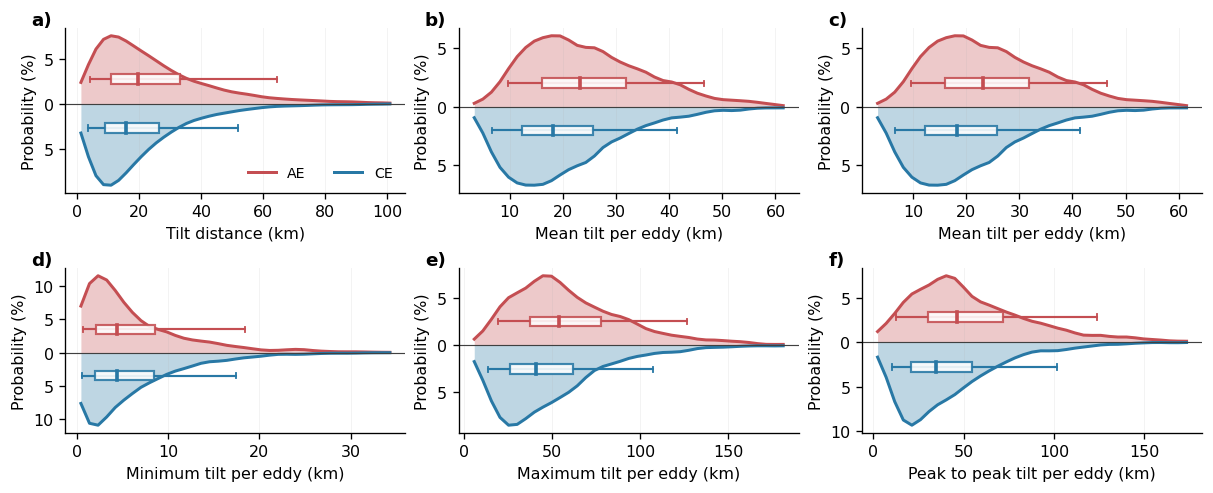

In [4]:
metrics=[
 ('TiltDis','','Tilt distance (km)',True,tilt_data),
 ('mean_tilt','','Mean tilt per eddy (km)',False,overall_eddy),
 ('mean_tilt','','Mean tilt per eddy (km)',False,overall_eddy),
 ('min_tilt','','Minimum tilt per eddy (km)',False,overall_eddy),
 ('max_tilt','','Maximum tilt per eddy (km)',False,overall_eddy),
 ('tilt_range','','Peak to peak tilt per eddy (km)',False,overall_eddy)]
fig,axes=plt.subplots(2,3,figsize=(10,4),constrained_layout=True)
for i,(ax,(column,title,xlabel,daily,source)) in enumerate(zip(axes.flat,metrics)):
    mirrored_density_box(ax,source,column,title,xlabel,daily=daily,bins=GLOBAL_TILT_BINS if daily else None,show_legend=i==0)
    panel_label(ax,chr(97+i))
# finish_figure(fig,'01_overall_tilt_census','Overall AE and CE tilt-distance census')

## Figure 2 — Upstream and downstream census
The upstream sector is S1 + U1 + U2; the downstream sector is S2 + D1 + D2. Daily tilt uses common bins.

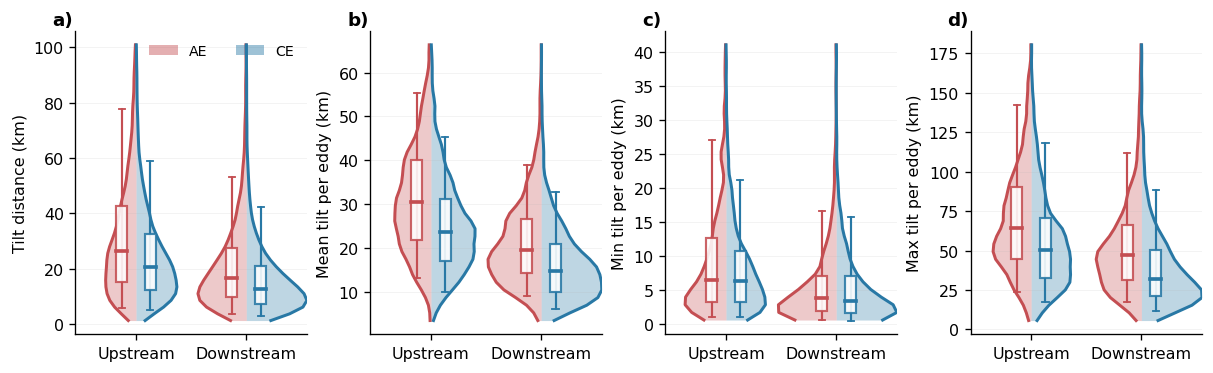

In [5]:
upstream_daily=tilt_data[tilt_data.Region.isin(UPSTREAM_REGIONS)].copy()
downstream_daily=tilt_data[tilt_data.Region.isin(DOWNSTREAM_REGIONS)].copy()
daily_groups=[('Upstream',upstream_daily),('Downstream',downstream_daily)]
eddy_groups=[('Upstream',make_eddy_summary(upstream_daily)),('Downstream',make_eddy_summary(downstream_daily))]
fig,axes=plt.subplots(1,4,figsize=(10,3),constrained_layout=True, sharey=False)
vertical_split_violin_box(axes[0],daily_groups,'TiltDis','','Tilt distance (km)',daily=True,bins=GLOBAL_TILT_BINS,show_legend=True)
vertical_split_violin_box(axes[1],eddy_groups,'mean_tilt','','Mean tilt per eddy (km)')
vertical_split_violin_box(axes[2],eddy_groups,'min_tilt','','Min tilt per eddy (km)')
vertical_split_violin_box(axes[3],eddy_groups,'max_tilt','','Max tilt per eddy (km)')
for i,ax in enumerate(axes): panel_label(ax,chr(97+i))
# finish_figure(fig,'02_upstream_downstream','Upstream–downstream contrast in AE and CE tilt distance')

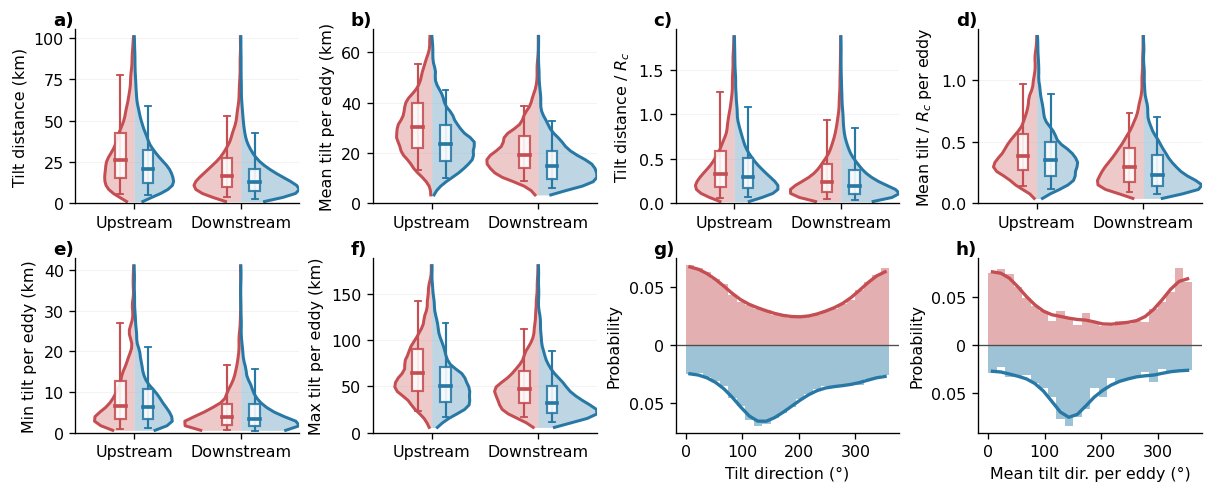

In [6]:
from matplotlib.ticker import FuncFormatter

upstream_daily=tilt_data[tilt_data.Region.isin(UPSTREAM_REGIONS)].copy()
downstream_daily=tilt_data[tilt_data.Region.isin(DOWNSTREAM_REGIONS)].copy()
daily_groups=[('Upstream',upstream_daily),('Downstream',downstream_daily)]
eddy_groups=[('Upstream',make_eddy_summary(upstream_daily)),('Downstream',make_eddy_summary(downstream_daily))]
fig,axes=plt.subplots(2,4,figsize=(10,4),constrained_layout=True, sharey=False)
vertical_split_violin_box(axes[0,0],daily_groups,'TiltDis','','Tilt distance (km)',daily=True,bins=GLOBAL_TILT_BINS,show_legend=False)
vertical_split_violin_box(axes[0,1],eddy_groups,'mean_tilt','','Mean tilt per eddy (km)')

vertical_split_violin_box(axes[0,2],daily_groups,'tilt_over_Rc','',r'Tilt distance / $R_c$',daily=True,bins=GLOBAL_TILT_RC_BINS)
vertical_split_violin_box(axes[0,3],eddy_groups,'mean_tilt_over_Rc','',r'Mean tilt / $R_c$ per eddy')

vertical_split_violin_box(axes[1,0],eddy_groups,'min_tilt','','Min tilt per eddy (km)')
vertical_split_violin_box(axes[1,1],eddy_groups,'max_tilt','','Max tilt per eddy (km)')

dir_bins = np.arange(0, 361, 15)
# Daily tilt direction
tilt.mirrored_hist(
    axes[1,2],
    tilt_data.loc[tilt_data.Cyc == 'AE', 'TiltDir'],
    tilt_data.loc[tilt_data.Cyc == 'CE', 'TiltDir'],
    dir_bins,
    'Tilt direction (°)',
    normalize=True,
    colors=(AE_COLOUR, CE_COLOUR)
)

# Circular mean direction for each eddy
eddy_dir = (
    tilt_data.dropna(subset=['TiltDir'])
    .assign(sin=np.sin(np.deg2rad(tilt_data.TiltDir)),
            cos=np.cos(np.deg2rad(tilt_data.TiltDir)))
    .groupby(['Cyc', 'Eddy'])[['sin', 'cos']].mean()
    .reset_index()
)

eddy_dir['mean_dir'] = (
    np.rad2deg(np.arctan2(eddy_dir.sin, eddy_dir.cos)) % 360
)

tilt.mirrored_hist(
    axes[1,3],
    eddy_dir.loc[eddy_dir.Cyc == 'AE', 'mean_dir'],
    eddy_dir.loc[eddy_dir.Cyc == 'CE', 'mean_dir'],
    dir_bins,
    'Mean tilt dir. per eddy (°)',
    normalize=True,
    colors=(AE_COLOUR, CE_COLOUR)
)

axes[1,2].yaxis.set_major_formatter(FuncFormatter(lambda y,_: f'{abs(y):g}'))
axes[1,3].yaxis.set_major_formatter(FuncFormatter(lambda y,_: f'{abs(y):g}'))

for i, ax in enumerate(axes.flatten()): 
    panel_label(ax,chr(97+i))
    if i<6: ax.set_ylim(0, None)

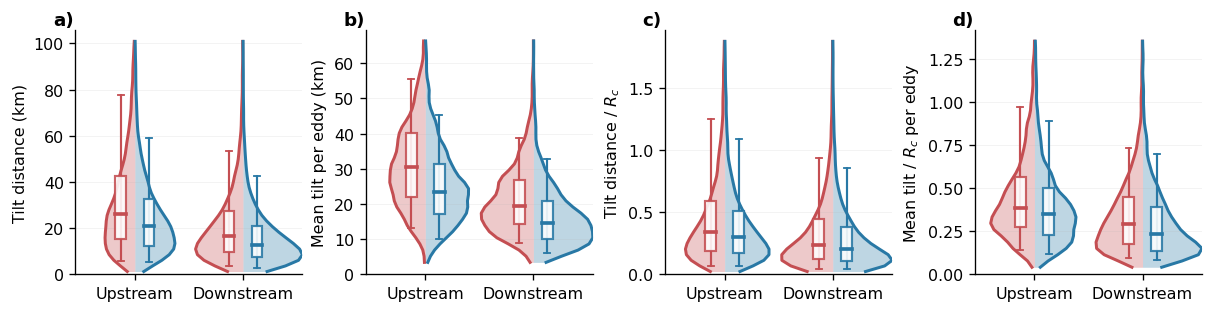

In [7]:
upstream_daily=tilt_data[tilt_data.Region.isin(UPSTREAM_REGIONS)].copy()
downstream_daily=tilt_data[tilt_data.Region.isin(DOWNSTREAM_REGIONS)].copy()
daily_groups=[('Upstream',upstream_daily),('Downstream',downstream_daily)]
eddy_groups=[('Upstream',make_eddy_summary(upstream_daily)),('Downstream',make_eddy_summary(downstream_daily))]

fig,axes=plt.subplots(1,4,figsize=(10,2.5),constrained_layout=True)

vertical_split_violin_box(axes[0],daily_groups,'TiltDis','','Tilt distance (km)',daily=True,bins=GLOBAL_TILT_BINS,show_legend=False)
vertical_split_violin_box(axes[1],eddy_groups,'mean_tilt','','Mean tilt per eddy (km)')
vertical_split_violin_box(axes[2],daily_groups,'tilt_over_Rc','',r'Tilt distance / $R_c$',daily=True,bins=GLOBAL_TILT_RC_BINS)
vertical_split_violin_box(axes[3],eddy_groups,'mean_tilt_over_Rc','',r'Mean tilt / $R_c$ per eddy')

for i,ax in enumerate(axes):
    panel_label(ax,chr(97+i))
    ax.set_ylim(0,None)

2081.0
2025.0


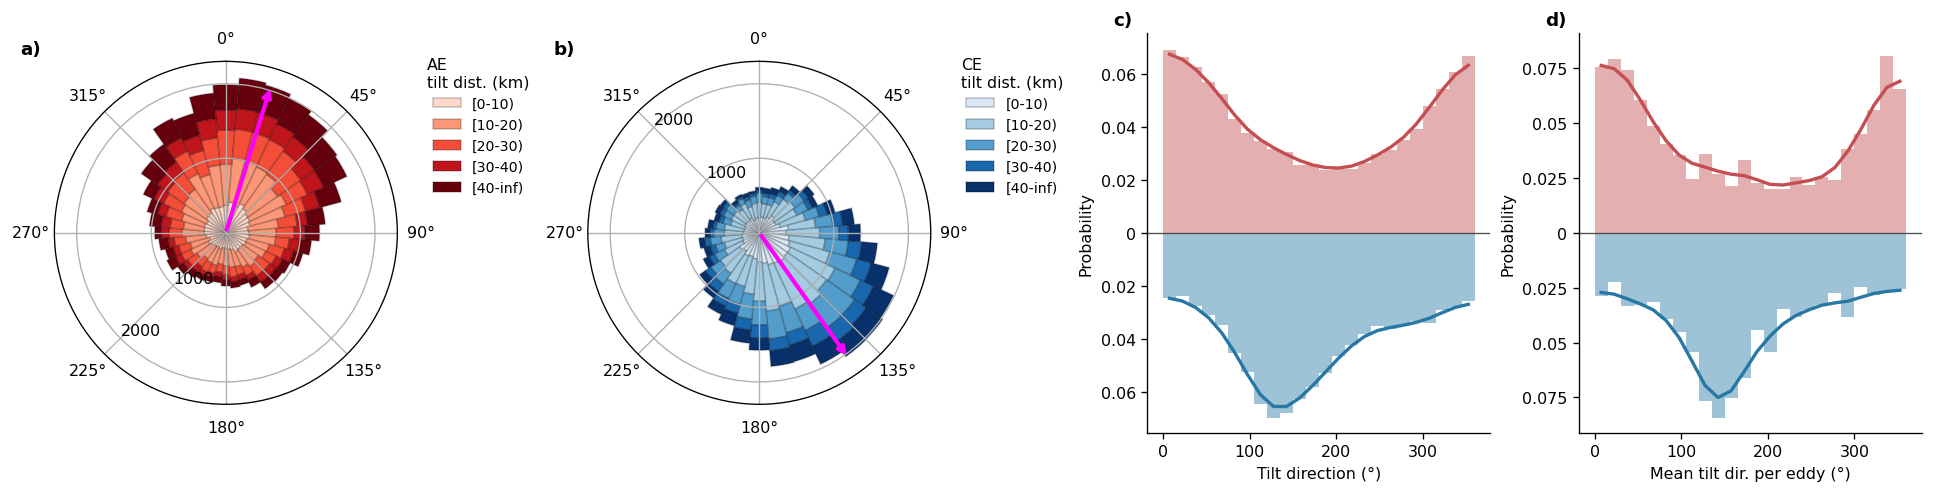

In [8]:
mag_bins = [0, 10, 20, 30, 40, np.inf]
fig=plt.figure(figsize=(16,4),constrained_layout=True)
gs=fig.add_gridspec(1,4)
axs=[fig.add_subplot(gs[0,i],projection='polar') if i<2 else fig.add_subplot(gs[0,i]) for i in range(4)]

for ax,cyc,colors in zip(axs[:2],['AE','CE'],[plt.cm.Reds(np.linspace(.15,1,len(mag_bins)-1)),plt.cm.Blues(np.linspace(.15,1,len(mag_bins)-1))]):
    df=df_eddies[(df_eddies.Cyc==cyc)&df_eddies.Region.isin(['U1','U2','D1','D2'])].dropna(subset=['TiltDir','TiltDis'])
    tilt.plot_windrose(ax,df,title='',mag_bins=mag_bins,colors=colors,step=1000,rlim=2300)
    th=np.deg2rad(df.TiltDir); th=np.arctan2(np.mean(np.sin(th)),np.mean(np.cos(th)))
    ax.annotate('',xy=(th,.9*ax.get_ylim()[1]),xytext=(th,0),arrowprops=dict(arrowstyle='->',lw=2.5,color='magenta'))
    ax.legend(title=f'{cyc}\ntilt dist. (km)',loc='upper left',bbox_to_anchor=(1.05,1.05),frameon=False)

dir_bins=np.arange(0,361,15)
tilt.mirrored_hist(axs[2],tilt_data.loc[tilt_data.Cyc=='AE','TiltDir'],tilt_data.loc[tilt_data.Cyc=='CE','TiltDir'],dir_bins,'Tilt direction (°)',normalize=True,colors=(AE_COLOUR,CE_COLOUR))

eddy_dir=(tilt_data.dropna(subset=['TiltDir']).assign(sin=lambda x:np.sin(np.deg2rad(x.TiltDir)),cos=lambda x:np.cos(np.deg2rad(x.TiltDir))).groupby(['Cyc','Eddy'])[['sin','cos']].mean().reset_index())
eddy_dir['mean_dir']=np.rad2deg(np.arctan2(eddy_dir.sin,eddy_dir.cos))%360
tilt.mirrored_hist(axs[3],eddy_dir.loc[eddy_dir.Cyc=='AE','mean_dir'],eddy_dir.loc[eddy_dir.Cyc=='CE','mean_dir'],dir_bins,'Mean tilt dir. per eddy (°)',normalize=True,colors=(AE_COLOUR,CE_COLOUR))

for ax in axs[2:]: ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_:f'{abs(y):g}'))
for i,ax in enumerate(axs): panel_label(ax,chr(97+i))

plt.show()